# Proiect Machine Learning – Clasificare

## Analiza nivelului de stres pe baza utilizarii social media, somnului si stilului de viata

**Student:** Maria Timoc
**Dataset:** Social Media Usage vs Sleep, Stress & Productivity
**Target:** stress_level

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("Datasets/social_media_sleep_stress_productivity_11000.csv")

df = df.sample(n=2000, random_state=42)

df.head()

,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score,stress_level,platform
107,108,30,8.45,1.18,4.33,86,9.67,84.45,Medium,YouTube
5484,5485,46,1.92,6.58,3.60,19,7.24,13.60,High,Instagram
6998,6999,21,3.20,2.79,5.15,58,3.48,10.22,Medium,Snapchat
3984,3985,45,11.86,4.74,7.95,116,6.87,23.55,Low,YouTube
3111,3112,24,7.56,3.23,7.32,101,9.16,98.37,Low,YouTube


## 4.1 Definirea problemei

Scopul acestei probleme de clasificare este prezicerea nivelului de stres al unei persoane pe baza unor informatii legate de utilizarea social media, timpul petrecut in fata ecranelor, somn, exercitiu fizic si activitate de studiu sau munca.

Variabila tinta este stress_level.

Clasele existente sunt:

- Low – nivel scazut de stres
- Medium – nivel mediu de stres
- High – nivel ridicat de stres

Caracteristicile de intrare sunt: age, daily_screen_time_hours, social_media_hours, sleep_hours, exercise_minutes, study_work_hours si platform.

Problema este relevanta deoarece utilizarea excesiva a tehnologiei si lipsa somnului pot influenta starea de bine si nivelul de stres. Un model de machine learning poate ajuta la identificarea unor tipare intre stilul de viata digital si stres.

Am ales aceasta problema deoarece este actuala, usor de inteles si permite o analiza clara prin grafice, metrici si modele de clasificare.

## 4.2 Analiza exploratorie a datelor si pregatirea lor

In aceasta etapa se urmareste intelegerea structurii dataset-ului, verificarea calitatii datelor si identificarea relatiilor dintre variabile.

Vor fi analizate:
- dimensiunea dataset-ului
- tipurile de date
- valorile lipsa
- eventualele anomalii
- distributia variabilelor numerice
- relatia dintre caracteristici si Exam_Score

Scopul este pregatirea corecta a datelor pentru modelele de machine learning, astfel incat acestea sa poata invata cat mai eficient din informatiile disponibile.

Prin analiza exploratorie se pot observa tipare importante, variabile influente si eventuale probleme care necesita corectare inainte de antrenarea modelelor.

In [7]:
df.shape

(2000, 10)

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 2000 entries, 107 to 5496
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  2000 non-null   int64  
 1   age                      2000 non-null   int64  
 2   daily_screen_time_hours  2000 non-null   float64
 3   social_media_hours       2000 non-null   float64
 4   sleep_hours              2000 non-null   float64
 5   exercise_minutes         2000 non-null   int64  
 6   study_work_hours         2000 non-null   float64
 7   productivity_score       2000 non-null   float64
 8   stress_level             2000 non-null   str    
 9   platform                 2000 non-null   str    
dtypes: float64(5), int64(3), str(2)
memory usage: 171.9 KB


In [9]:
df.describe()

,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,5485.248000,32.629000,6.394820,4.223000,6.004025,60.453500,5.580730,51.342225
std,3190.900978,9.674459,3.157629,2.151072,1.748133,34.556315,2.592611,28.908379
min,1.000000,16.000000,1.010000,0.500000,3.000000,0.000000,1.000000,1.000000
25%,2854.250000,24.000000,3.660000,2.350000,4.477500,31.000000,3.360000,25.702500
50%,5440.500000,33.000000,6.410000,4.225000,5.990000,61.000000,5.670000,51.705000
75%,8209.750000,41.000000,9.122500,6.070000,7.520000,90.000000,7.860000,76.715000
max,11000.000000,49.000000,12.000000,8.000000,9.000000,119.000000,10.000000,99.820000


In [10]:
df.isnull().sum()

user_id                    0
age                        0
daily_screen_time_hours    0
social_media_hours         0
sleep_hours                0
exercise_minutes           0
study_work_hours           0
productivity_score         0
stress_level               0
platform                   0
dtype: int64

In [11]:
df["stress_level"].value_counts()

stress_level
Medium    682
Low       672
High      646
Name: count, dtype: int64

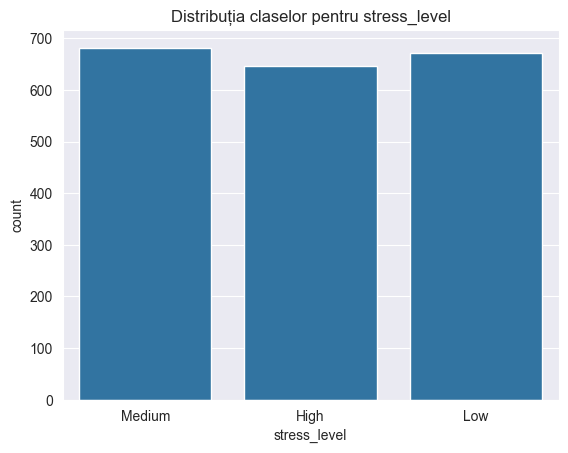

In [12]:
sns.countplot(data=df, x="stress_level")
plt.title("Distribuția claselor pentru stress_level")
plt.show()

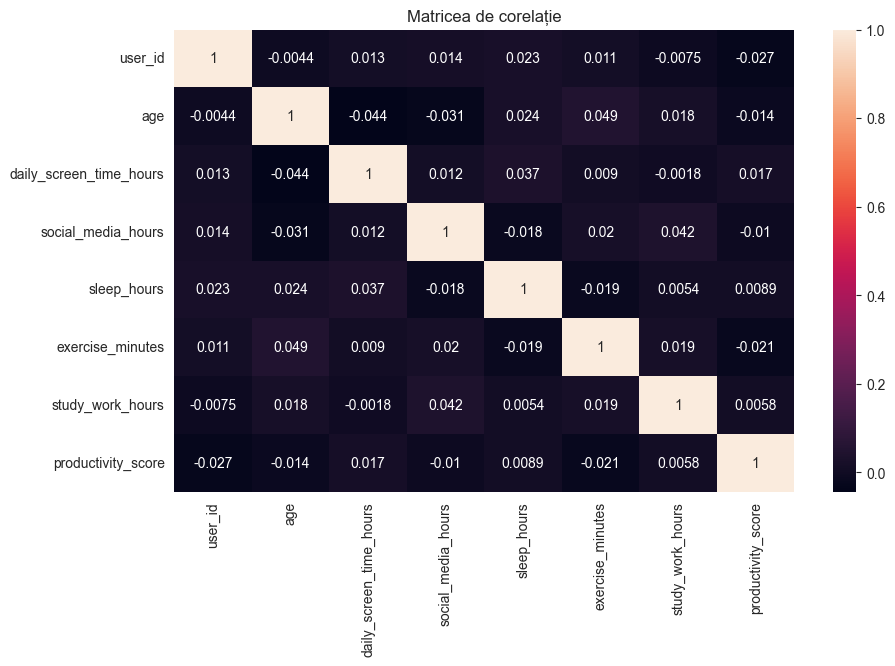

In [13]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Matricea de corelație")
plt.show()

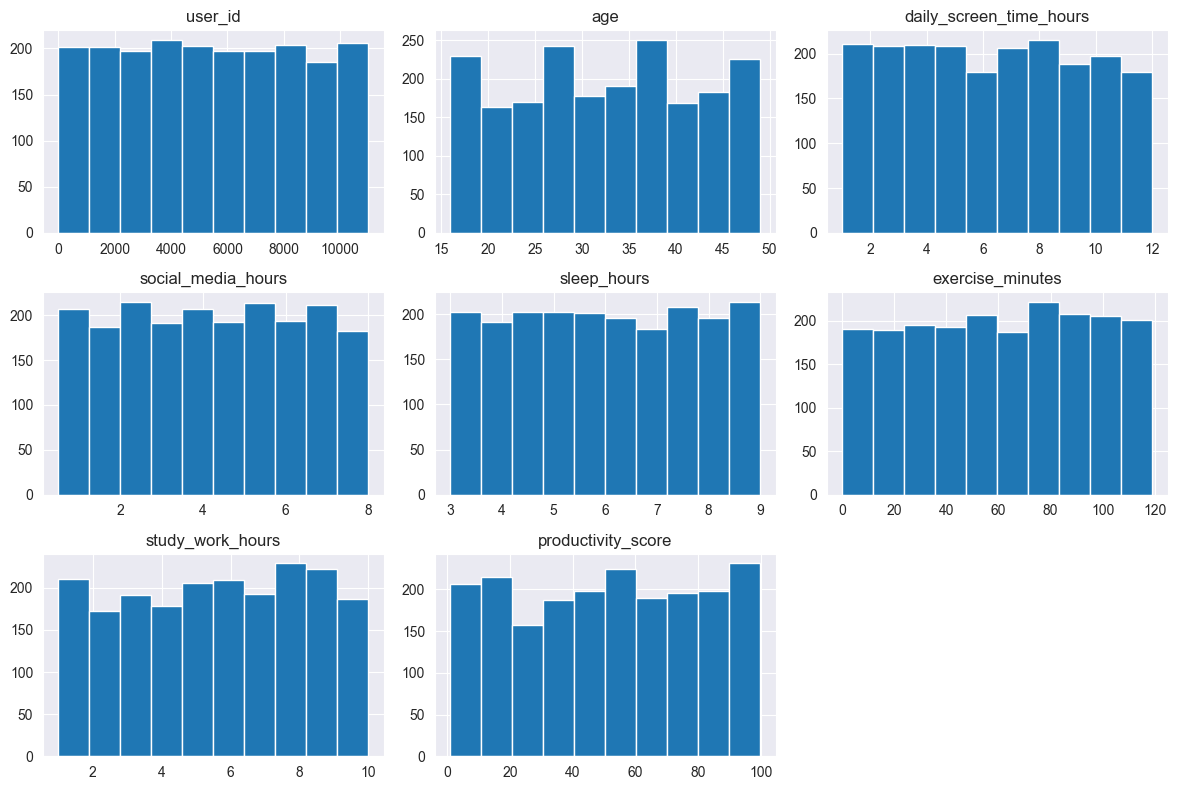

In [14]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

## 4.2 Analiza exploratorie a datelor

### Observatii:

Dataset-ul contine 2000 observatii si 10 variabile, fara valori lipsa.

Distributia claselor pentru stress_level este echilibrata, ceea ce este favorabil pentru antrenarea modelelor de clasificare.

Histogramele indica distributii relativ uniforme pentru majoritatea variabilelor numerice.

Matricea de corelatie arata corelatii liniare slabe intre variabile, sugerand ca relatiile pot fi mai complexe si pot necesita modele capabile sa surprinda pattern-uri non-liniare.

## 4.3 Antrenarea si compararea modelelor de baza

In aceasta etapa am antrenat si comparat mai multi algoritmi de clasificare pentru a determina care dintre ei poate prezice cel mai bine nivelul de stres (stress_level) pe baza variabilelor disponibile in dataset.

Conform cerintei proiectului, datele au fost impartite astfel:

- 75% pentru antrenare
- 25% pentru testare si validare

Scopul acestei etape este compararea performantei mai multor algoritmi folosind aceleasi date si aceleasi criterii de evaluare.

### Algoritmi folositi:

- Gaussian Naive Bayes
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Xtreme Gradient Boost (XGBoost)
- Categorical Boost (CatBoost)
- Explainable Boosting Machine (EBM)

### Pasii realizati:

Pentru fiecare algoritm:

1. Am antrenat modelul pe setul de training
2. Am realizat predictii pe setul de test
3. Am calculat metricile de performanta:
   - Accuracy
   - Precision
   - Recall
   - F1-Score
   - ROC-AUC Score
4. Am generat matricea de confuzie (Confusion Matrix)
5. Am comparat rezultatele intr-un tabel comparativ Markdown

### Metricile utilizate:

#### Accuracy
Procentul total al predictiilor corecte.

#### Precision
Masoara cat de precise sunt predictiile realizate de model.

#### Recall
Arata cat de bine identifica modelul exemplele reale.

#### F1-Score
Combina Precision si Recall intr-o singura valoare echilibrata.

#### ROC-AUC Score
Evalueaza capacitatea modelului de a separa corect clasele si este important pentru comparatia generala a performantei.

#### Confusion Matrix
Permite analiza detaliata a clasificarilor corecte si gresite pentru fiecare clasa.

### De ce folosesc mai multi algoritmi:

Fiecare model are caracteristici diferite:

#### Gaussian Naive Bayes
- rapid
- simplu
- bun ca punct de plecare

#### Logistic Regression
- interpretabil
- eficient pentru relatii mai simple

#### Decision Tree
- usor de inteles
- poate surprinde reguli complexe

#### Random Forest
- mai stabil
- reduce overfitting-ul

#### SVM
- performant pentru clasificari mai complexe

#### KNN
- bazat pe similaritatea dintre exemple

#### XGBoost
- foarte performant
- optimizeaza iterativ erorile
- utilizat frecvent in competitii ML

#### CatBoost
- eficient pentru date cu variabile categorice
- necesita mai putin preprocessing

#### Explainable Boosting Machine (EBM)
- ofera performanta ridicata
- mentine interpretabilitatea modelului

### Scop final:

La final, toate modelele sunt comparate folosind aceleasi metrici pentru a identifica algoritmii cu cele mai bune rezultate.

Primele 5 modele vor fi selectate pentru etapele urmatoare de optimizare, analiza ROC-AUC si interpretare detaliata.

## Concluzii 4.3

In aceasta etapa au fost evaluate 9 modele de clasificare utilizand aceleasi date si aceleasi metrici.

Pe baza scorului F1, cele mai bune performante au fost obtinute de:

- Random Forest
- SVM
- XGBoost
- CatBoost
- Gaussian Naive Bayes

Primele 5 modele selectate vor fi utilizate in etapa urmatoare pentru optimizare de hiperparametri si analiza suplimentara.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [16]:
le_target = LabelEncoder()
df["stress_level_encoded"] = le_target.fit_transform(df["stress_level"])
le_platform = LabelEncoder()
df["platform"] = le_platform.fit_transform(df["platform"])
X = df.drop(["stress_level", "stress_level_encoded", "user_id"], axis=1)
y = df["stress_level_encoded"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    try:
        y_prob = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
    except:
        roc_auc = "N/A"

    cm = confusion_matrix(y_test, y_pred)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix": cm
    }

In [20]:
models = [
    ("Gaussian Naive Bayes", GaussianNB(), X_train_scaled, X_test_scaled),
    ("Logistic Regression", LogisticRegression(max_iter=1000), X_train_scaled, X_test_scaled),
    ("Decision Tree", DecisionTreeClassifier(random_state=42), X_train, X_test),
    ("Random Forest", RandomForestClassifier(random_state=42), X_train, X_test),
    ("SVM", SVC(probability=True, random_state=42), X_train_scaled, X_test_scaled),
    ("KNN", KNeighborsClassifier(), X_train_scaled, X_test_scaled),
    ("XGBoost", XGBClassifier(eval_metric="mlogloss", random_state=42), X_train, X_test),
    ("CatBoost", CatBoostClassifier(verbose=0, random_state=42), X_train, X_test),
    ("EBM", ExplainableBoostingClassifier(random_state=42, interactions=0), X_train, X_test)
]


In [21]:
results = []

for name, model, train_data, test_data in models:
    result = evaluate_model(model, train_data, test_data, y_train, y_test, name)
    results.append(result)

results_df = pd.DataFrame(results)

results_table = results_df.drop("Confusion Matrix", axis=1)
results_table = results_table.sort_values(by="F1 Score", ascending=False)

results_table

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Random Forest,0.360,0.360516,0.360,0.360163,0.526769
4,SVM,0.352,0.352344,0.352,0.352137,0.447327
6,XGBoost,0.332,0.332975,0.332,0.332259,0.517756
7,CatBoost,0.330,0.330980,0.330,0.330388,0.509417
0,Gaussian Naive Bayes,0.332,0.338346,0.332,0.326980,0.498101
5,KNN,0.330,0.330919,0.330,0.326128,0.497078
8,EBM,0.344,0.357559,0.344,0.322315,0.513774
1,Logistic Regression,0.314,0.311730,0.314,0.307102,0.474884
2,Decision Tree,0.300,0.300441,0.300,0.300029,0.475130


In [22]:
top_5_models = results_table.head(5)

top_5_models

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Random Forest,0.360,0.360516,0.360,0.360163,0.526769
4,SVM,0.352,0.352344,0.352,0.352137,0.447327
6,XGBoost,0.332,0.332975,0.332,0.332259,0.517756
7,CatBoost,0.330,0.330980,0.330,0.330388,0.509417
0,Gaussian Naive Bayes,0.332,0.338346,0.332,0.326980,0.498101


In [23]:
for result in results:
    print(result["Model"])
    print("Accuracy:", result["Accuracy"])
    print("Precision:", result["Precision"])
    print("Recall:", result["Recall"])
    print("F1 Score:", result["F1 Score"])
    print("ROC-AUC:", result["ROC-AUC"])
    print("Confusion Matrix:")
    print(result["Confusion Matrix"])
    print()

Gaussian Naive Bayes
Accuracy: 0.332
Precision: 0.33834648661025507
Recall: 0.332
F1 Score: 0.32698041352174495
ROC-AUC: 0.498100994495335
Confusion Matrix:
[[37 56 69]
 [22 56 90]
 [42 55 73]]

Logistic Regression
Accuracy: 0.314
Precision: 0.3117303629941406
Recall: 0.314
F1 Score: 0.30710155415412077
ROC-AUC: 0.4748839876821714
Confusion Matrix:
[[32 54 76]
 [32 52 84]
 [49 48 73]]

Decision Tree
Accuracy: 0.3
Precision: 0.3004408715887455
Recall: 0.3
F1 Score: 0.3000294169871209
ROC-AUC: 0.4751301416045612
Confusion Matrix:
[[50 53 59]
 [62 51 55]
 [62 59 49]]

Random Forest
Accuracy: 0.36
Precision: 0.36051622967603114
Recall: 0.36
F1 Score: 0.36016273557379286
ROC-AUC: 0.5267686201377035
Confusion Matrix:
[[59 52 51]
 [42 61 65]
 [54 56 60]]

SVM
Accuracy: 0.352
Precision: 0.3523444215484251
Recall: 0.352
F1 Score: 0.35213676470588234
ROC-AUC: 0.4473270522312846
Confusion Matrix:
[[61 50 51]
 [46 59 63]
 [51 63 56]]

KNN
Accuracy: 0.33
Precision: 0.33091881064162754
Recall: 0.33


## Concluzii 4.3

In aceasta etapa au fost evaluate 9 modele de clasificare utilizand aceleasi date si aceleasi metrici.

Pe baza scorului F1, cele mai bune performante au fost obtinute de:

1. Random Forest
2. SVM
3. XGBoost
4. CatBoost
5. Gaussian Naive Bayes

Random Forest a obtinut cel mai bun echilibru general intre Accuracy, Precision, Recall si F1-Score.

Rezultatele generale indica faptul ca problema de clasificare este una dificila, deoarece scorurile sunt relativ apropiate si moderate pentru toate modelele.

Primele 5 modele selectate vor fi utilizate in etapa urmatoare pentru optimizare de hiperparametri si analiza suplimentara.

# 4.4 Ajustarea hiperparametrilor

In aceasta etapa am selectat primele 5 modele obtinute in etapa anterioara si am aplicat `GridSearchCV` pentru a cauta combinatii mai bune de hiperparametri.

Scopul este imbunatatirea performantei modelelor fata de varianta de baza si identificarea celui mai bun model dupa optimizare.

Modelele selectate pentru tuning sunt:

- Random Forest
- SVM
- XGBoost
- CatBoost
- Gaussian Naive Bayes

In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.01, 0.1]
}

cat_params = {
    "iterations": [100, 200],
    "depth": [4, 6],
    "learning_rate": [0.01, 0.1]
}

nb_params = {
    "var_smoothing": [1e-9, 1e-8, 1e-7]
}

In [26]:
def tune_model(model, params, X_train, y_train):
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(X_train, y_train)

    best_index = grid.best_index_
    train_score = grid.cv_results_["mean_train_score"][best_index]
    overfit_gap = train_score - grid.best_score_

    return {
        "best_model": grid.best_estimator_,
        "best_params": grid.best_params_,
        "best_cv_score": grid.best_score_,
        "best_train_score": train_score,
        "overfit_gap": overfit_gap,
        "grid_object": grid
    }

In [27]:
rf_result = tune_model(RandomForestClassifier(random_state=42), rf_params, X_train, y_train)
svm_result = tune_model(SVC(probability=True, random_state=42), svm_params, X_train_scaled, y_train)
xgb_result = tune_model(XGBClassifier(eval_metric="mlogloss", random_state=42), xgb_params, X_train, y_train)
cat_result = tune_model(CatBoostClassifier(verbose=0, random_state=42), cat_params, X_train, y_train)
nb_result = tune_model(GaussianNB(), nb_params, X_train_scaled, y_train)

best_rf = rf_result["best_model"]
best_svm = svm_result["best_model"]
best_xgb = xgb_result["best_model"]
best_cat = cat_result["best_model"]
best_nb = nb_result["best_model"]

In [28]:
tuning_results = pd.DataFrame([
    ["Random Forest", rf_result["best_cv_score"], rf_result["best_train_score"], rf_result["overfit_gap"], rf_result["best_params"]],
    ["SVM", svm_result["best_cv_score"], svm_result["best_train_score"], svm_result["overfit_gap"], svm_result["best_params"]],
    ["XGBoost", xgb_result["best_cv_score"], xgb_result["best_train_score"], xgb_result["overfit_gap"], xgb_result["best_params"]],
    ["CatBoost", cat_result["best_cv_score"], cat_result["best_train_score"], cat_result["overfit_gap"], cat_result["best_params"]],
    ["GaussianNB", nb_result["best_cv_score"], nb_result["best_train_score"], nb_result["overfit_gap"], nb_result["best_params"]]
], columns=["Model", "Best CV F1 Score", "Train F1 Score", "Overfit Gap", "Best Parameters"])

tuning_results

,Model,Best CV F1 Score,Train F1 Score,Overfit Gap,Best Parameters
0,Random Forest,0.341003,0.977671,0.636668,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
1,SVM,0.347143,0.379443,0.032300,"{'C': 0.1, 'kernel': 'linear'}"
2,XGBoost,0.351192,0.812750,0.461558,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
3,CatBoost,0.339794,0.740874,0.401080,"{'depth': 4, 'iterations': 200, 'learning_rate..."
4,GaussianNB,0.358269,0.389917,0.031648,{'var_smoothing': 1e-09}


In [29]:
optimized_models = [
    ("Random Forest Tuned", best_rf, X_train, X_test),
    ("SVM Tuned", best_svm, X_train_scaled, X_test_scaled),
    ("XGBoost Tuned", best_xgb, X_train, X_test),
    ("CatBoost Tuned", best_cat, X_train, X_test),
    ("GaussianNB Tuned", best_nb, X_train_scaled, X_test_scaled)
]

optimized_results = []

for name, model, train_data, test_data in optimized_models:
    result = evaluate_model(model, train_data, test_data, y_train, y_test, name)
    optimized_results.append(result)

optimized_results_df = pd.DataFrame(optimized_results)
optimized_results_table = optimized_results_df.drop("Confusion Matrix", axis=1)
optimized_results_table = optimized_results_table.sort_values(by="F1 Score", ascending=False)

optimized_results_table

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,CatBoost Tuned,0.378,0.378759,0.378,0.378076,0.526249
0,Random Forest Tuned,0.370,0.370387,0.370,0.370047,0.536989
2,XGBoost Tuned,0.366,0.367725,0.366,0.366101,0.529022
4,GaussianNB Tuned,0.332,0.338346,0.332,0.326980,0.498101
1,SVM Tuned,0.314,0.311875,0.314,0.307728,0.483076


## Concluzii 4.4

### Rezultate principale:

Dupa optimizare, modelul **CatBoost Tuned** a obtinut cea mai buna performanta generala, avand cel mai mare scor F1 pe setul de test (**F1 Score ≈ 0.378**), urmat de:

- Random Forest Tuned
- XGBoost Tuned

Acest rezultat indica faptul ca ajustarea hiperparametrilor a avut un impact pozitiv asupra performantei si a permis imbunatatirea modelelor fata de variantele de baza.

### Analiza overfitting-ului:

Pentru a controla riscul de overfitting, a fost utilizata validarea incrucisata (`cv=5`) si s-a analizat diferenta dintre scorul pe datele de antrenare si scorul de validare (`Overfit Gap`).

Observatiile arata ca:

- **Gaussian Naive Bayes** si **SVM** au avut cele mai mici valori ale Overfit Gap, ceea ce sugereaza o capacitate mai buna de generalizare.
- **Random Forest**, **XGBoost** si **CatBoost** au obtinut performante mai ridicate, dar au prezentat si valori mai mari ale Overfit Gap, indicand un risc mai mare de overfitting.

### Concluzie finala:

- **Cel mai performant model:** CatBoost Tuned
- **Cele mai stabile modele:** Gaussian Naive Bayes si SVM

# 4.5 Curbele de invatare

In aceasta etapa au fost analizate curbele de invatare pentru primele 5 modele optimizate, cu scopul de a evalua comportamentul acestora pe masura ce dimensiunea setului de antrenare creste.

Scopul principal este compararea scorurilor de antrenare si validare pentru a identifica scenarii de:

- Overfitting
- Underfitting
- Generalizare eficienta

Modelele analizate sunt:

- Random Forest Tuned
- SVM Tuned
- XGBoost Tuned
- CatBoost Tuned
- Gaussian Naive Bayes Tuned

Pentru fiecare model au fost generate grafice Learning Curve folosind validare incrucisata (`cv=5`), urmarindu-se evolutia scorului F1 Weighted pe seturile de training si validation.

### Ce se urmareste:

- Daca modelul invata excesiv datele de training (overfitting)
- Daca modelul are performante reduse atat pe training, cat si pe validation (underfitting)
- Daca modelul generalizeaza bine pe date noi

Aceasta etapa este importanta deoarece performanta ridicata singura nu este suficienta fara stabilitate si capacitate buna de generalizare.

In [30]:
from sklearn.model_selection import learning_curve

In [31]:
def plot_learning_curve(model, title, X, y):
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=5,
        scoring="f1_weighted",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    validation_mean = np.mean(validation_scores, axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training Score")
    plt.plot(train_sizes, validation_mean, marker="o", label="Validation Score")

    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Weighted Score")
    plt.legend()
    plt.grid()
    plt.show()

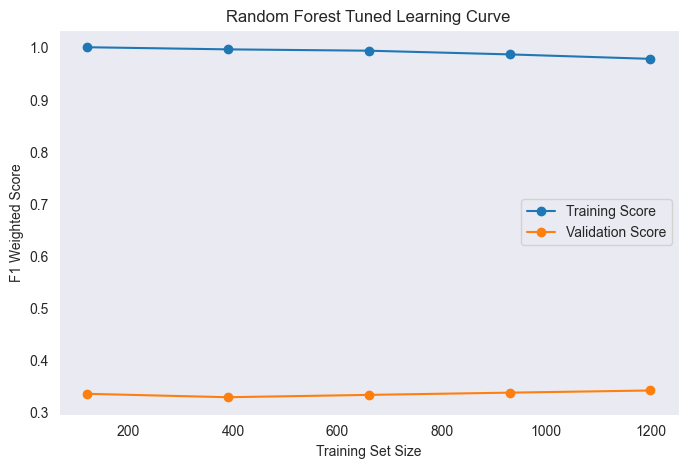

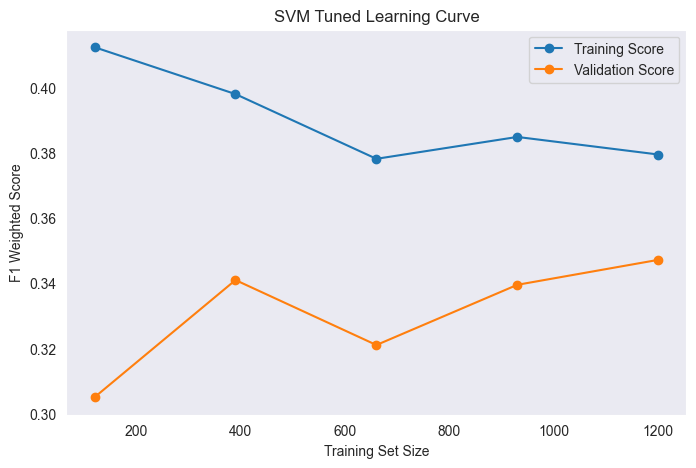

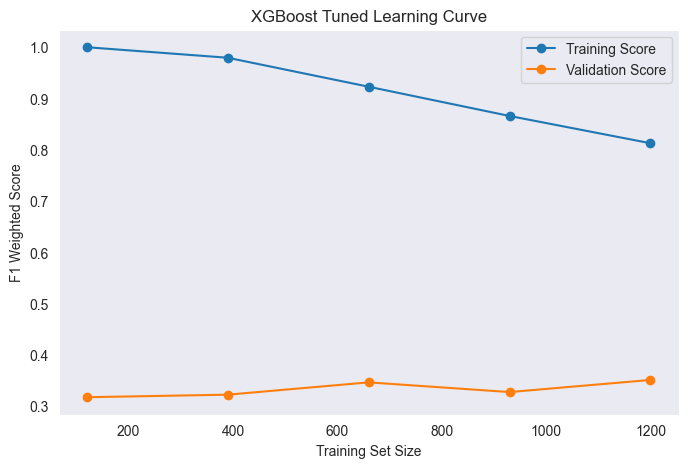

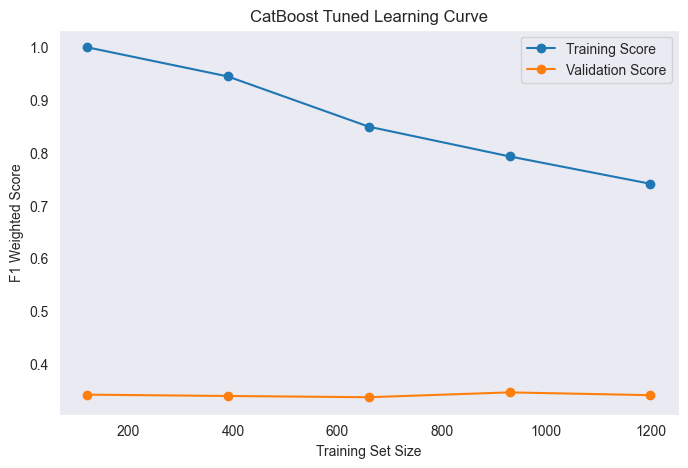

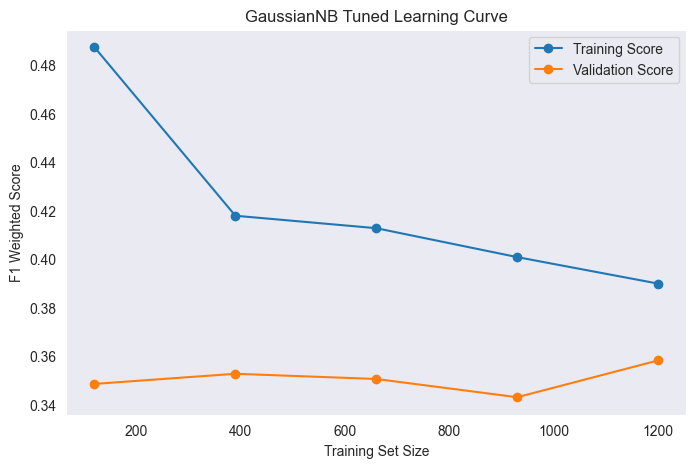

In [32]:
plot_learning_curve(best_rf, "Random Forest Tuned Learning Curve", X_train, y_train)

plot_learning_curve(best_svm, "SVM Tuned Learning Curve", X_train_scaled, y_train)

plot_learning_curve(best_xgb, "XGBoost Tuned Learning Curve", X_train, y_train)

plot_learning_curve(best_cat, "CatBoost Tuned Learning Curve", X_train, y_train)

plot_learning_curve(best_nb, "GaussianNB Tuned Learning Curve", X_train_scaled, y_train)

## Concluzii 4.5 – Curbele de invatare

In aceasta etapa au fost analizate curbele de invatare pentru cele 5 modele optimizate, prin compararea scorurilor de antrenare si validare in functie de dimensiunea setului de antrenare.

### Random Forest
Modelul prezinta un scor de antrenare aproape perfect, in timp ce scorul de validare ramane mult mai redus. Aceasta diferenta foarte mare indica un overfitting sever, modelul adaptandu-se excesiv la datele de antrenare.

### XGBoost
XGBoost prezinta un comportament similar cu Random Forest, avand scoruri foarte mari pe antrenare, dar performanta semnificativ mai scazuta pe validare. Acest lucru confirma existenta unui overfitting puternic.

### CatBoost
CatBoost obtine cele mai bune rezultate generale dupa tuning, insa curba de invatare indica totusi un decalaj important intre train si validation. Modelul ofera performanta ridicata, dar necesita monitorizare pentru a evita suprainvatarea.

### SVM
SVM prezinta diferente mai mici intre scorurile de antrenare si validare, ceea ce indica o generalizare mai buna. Desi performanta absoluta este mai redusa, modelul este mai echilibrat.

### Gaussian Naive Bayes
GaussianNB are cele mai apropiate curbe intre train si validation, ceea ce sugereaza cea mai stabila generalizare si cel mai redus risc de overfitting. Totusi, performanta sa globala ramane mai modesta.

## Concluzie finala

Analiza curbelor de invatare arata ca:

- Random Forest si XGBoost sufera de overfitting puternic;
- CatBoost ofera cea mai buna performanta generala, dar cu risc moderat de overfitting;
- SVM si GaussianNB sunt cele mai stabile din perspectiva generalizarii.

Prin urmare, CatBoost ramane modelul recomandat pentru performanta maxima, iar GaussianNB reprezinta cea mai robusta alegere din perspectiva stabilitatii.

# 4.6 Explicabilitatea si analiza SHAP

In aceasta etapa sunt analizate primele 3 modele optimizate utilizand SHAP (SHapley Additive exPlanations), pentru a interpreta modul in care caracteristicile influenteaza predictiile realizate.

Scopul este explicarea comportamentului modelelor perfectionate, atat la nivel global, cat si local, astfel incat sa se inteleaga de ce un anumit nivel de stres este prezis.

Modelele selectate sunt:

- CatBoost Tuned
- XGBoost Tuned
- Random Forest Tuned

## Cerinte urmarite:

### Explicatie globala:
Pentru fiecare model se analizeaza importanta caracteristicilor folosind:

- SHAP Summary Plot
- SHAP Bar Plot

Acestea evidentiaza cele mai importante variabile implicate in procesul de predictie.

### Explicatie locala:
Pentru predictii individuale se utilizeaza:

- SHAP Waterfall Plot
- SHAP Force Plot

Aceste grafice arata cum fiecare caracteristica contribuie pozitiv sau negativ la rezultatul final.

### Analiza caracteristicilor relevante:
Se realizeaza SHAP Scatter Plot pentru 2-3 caracteristici importante, pentru a observa cum valorile acestora influenteaza nivelul de stres prezis.

## Ce se urmareste:

- Identificarea celor mai importante 3 caracteristici
- Intelegerea modului in care valorile mari sau mici influenteaza predictia
- Explicarea unui exemplu concret de predictie
- Formularea unor concluzii clare privind comportamentul modelelor

## Importanta etapei:

Aceasta etapa valideaza daca modelele performante iau decizii logice si relevante.

Prin SHAP se poate demonstra:

- Ce variabile influenteaza cel mai mult stresul
- In ce directie influenteaza acestea predictia
- Daca relatiile identificate de model sunt coerente cu problema analizata

In [33]:
import warnings
warnings.filterwarnings("ignore")

import shap
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

shap.initjs()

In [34]:
top_models_shap = {
    "CatBoost": best_cat,
    "XGBoost": best_xgb,
    "Random Forest": best_rf
}

In [35]:
X_shap = X_test.sample(min(30, len(X_test)), random_state=42)

In [36]:
def shap_analysis_classification(model, X_sample, model_name, class_index=2):

    print(f"\n========== SHAP Analysis: {model_name} ==========")

    explainer = shap.Explainer(model.predict_proba, X_sample)
    shap_values = explainer(X_sample)

    shap_values_plot = shap_values[:, :, class_index]

    print("\n1. Summary plot")
    shap.summary_plot(shap_values_plot, X_sample)

    print("\n2. Bar plot")
    shap.plots.bar(shap_values_plot)

    print("\n3. Waterfall plot pentru prima predictie")
    shap.plots.waterfall(shap_values_plot[0])

    print("\n4. Force plot pentru prima predictie")
    display(shap.plots.force(shap_values_plot[0]))

    mean_importance = np.abs(shap_values_plot.values).mean(axis=0)
    top_3_idx = np.argsort(mean_importance)[-3:][::-1]

    top_features = []

    print("\nCele mai importante 3 caracteristici:")
    for idx in top_3_idx:
        feature_name = X_sample.columns[idx]
        top_features.append(feature_name)
        print(f"- {feature_name}: {mean_importance[idx]:.4f}")

    print("\n5. Scatter plots pentru cele mai importante 3 caracteristici")
    for feature_name in top_features:
        print(f"\nScatter plot pentru: {feature_name}")
        shap.plots.scatter(shap_values_plot[:, feature_name])

    return shap_values_plot, top_features

In [37]:
le_target.classes_

array(['High', 'Low', 'Medium'], dtype=object)

In [38]:
class_index = list(le_target.classes_).index("High")
class_index

0


========== SHAP Analysis: CatBoost ==========


ExactExplainer explainer: 31it [00:21,  1.41it/s]                        



1. Summary plot


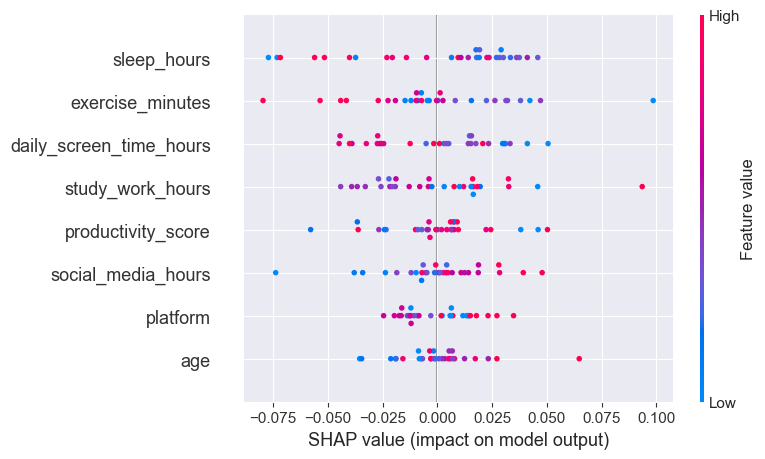


2. Bar plot


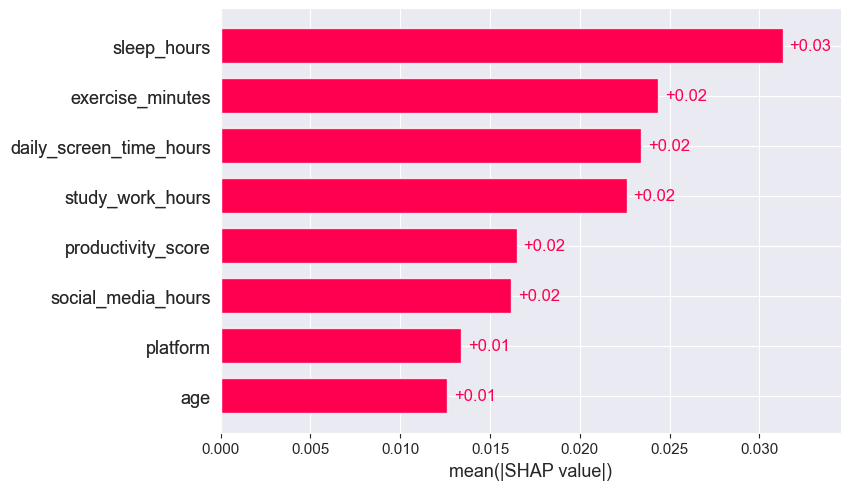


3. Waterfall plot pentru prima predictie


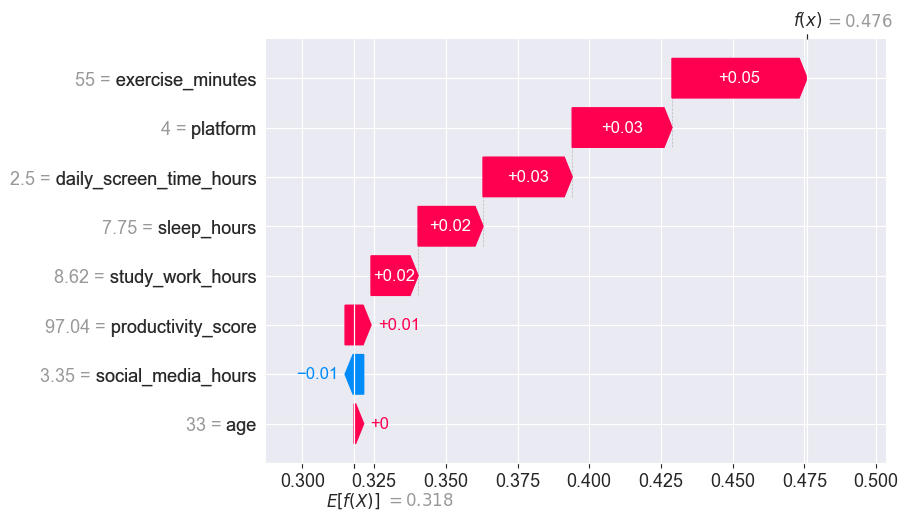


4. Force plot pentru prima predictie



Cele mai importante 3 caracteristici:
- sleep_hours: 0.0313
- exercise_minutes: 0.0244
- daily_screen_time_hours: 0.0234

5. Scatter plots pentru cele mai importante 3 caracteristici

Scatter plot pentru: sleep_hours


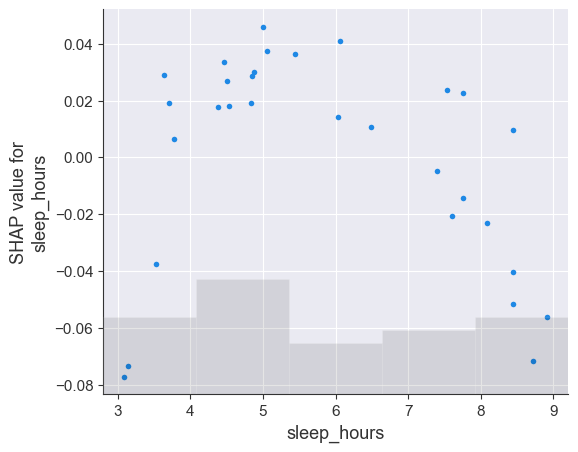


Scatter plot pentru: exercise_minutes


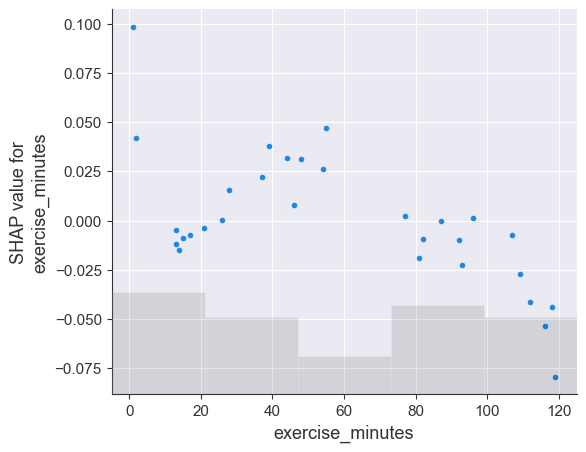


Scatter plot pentru: daily_screen_time_hours


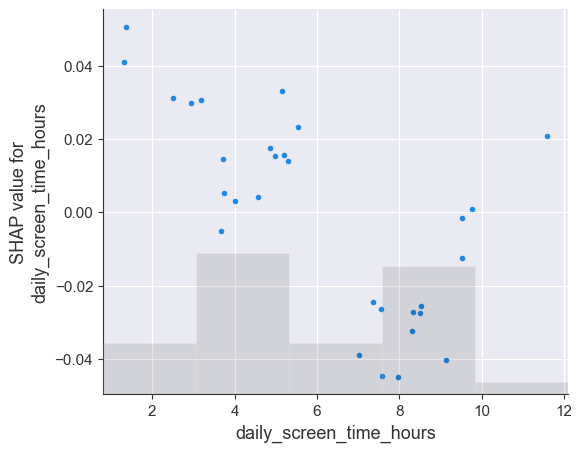

In [39]:
shap_values_cat, top_features_cat = shap_analysis_classification(
    best_cat,
    X_shap,
    "CatBoost",
    class_index
)


========== SHAP Analysis: XGBoost ==========

1. Summary plot


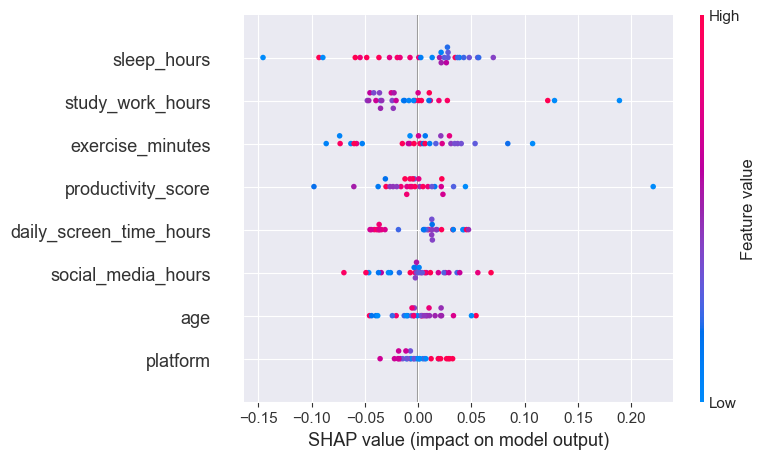


2. Bar plot


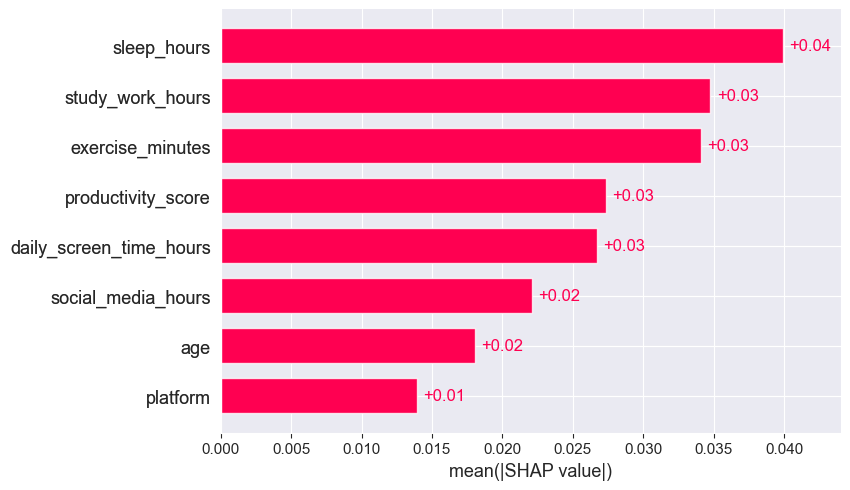


3. Waterfall plot pentru prima predictie


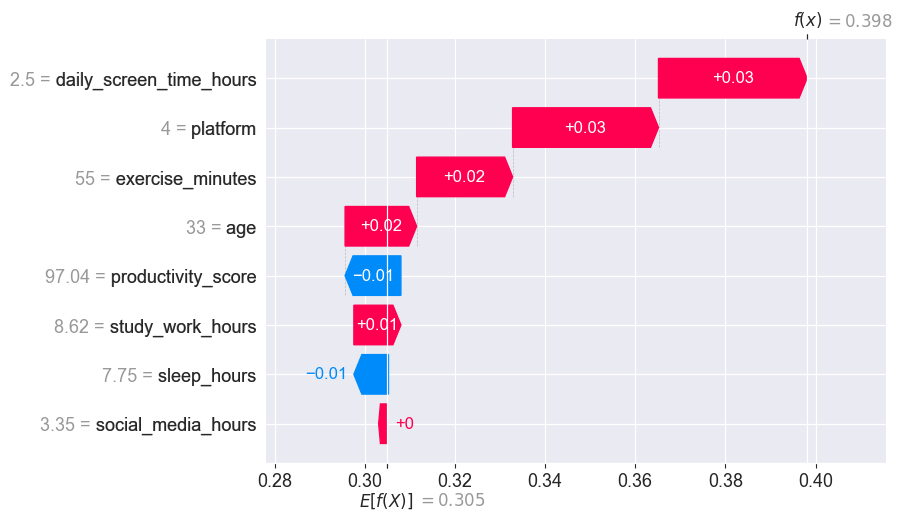


4. Force plot pentru prima predictie



Cele mai importante 3 caracteristici:
- sleep_hours: 0.0399
- study_work_hours: 0.0347
- exercise_minutes: 0.0341

5. Scatter plots pentru cele mai importante 3 caracteristici

Scatter plot pentru: sleep_hours


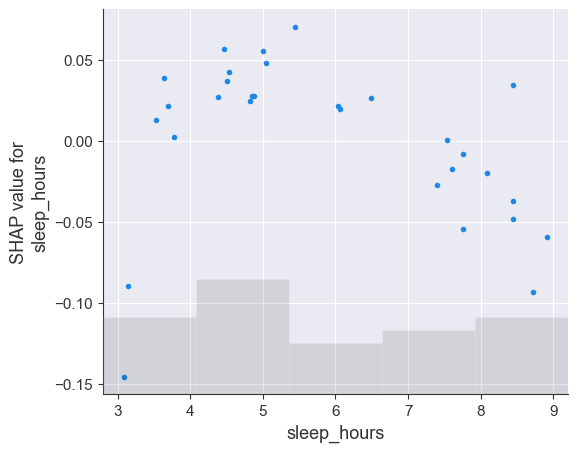


Scatter plot pentru: study_work_hours


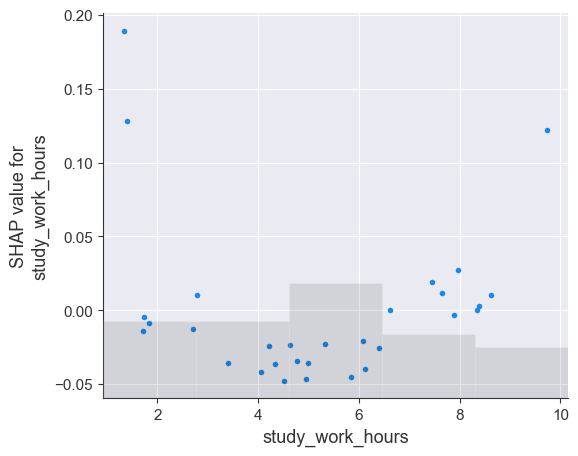


Scatter plot pentru: exercise_minutes


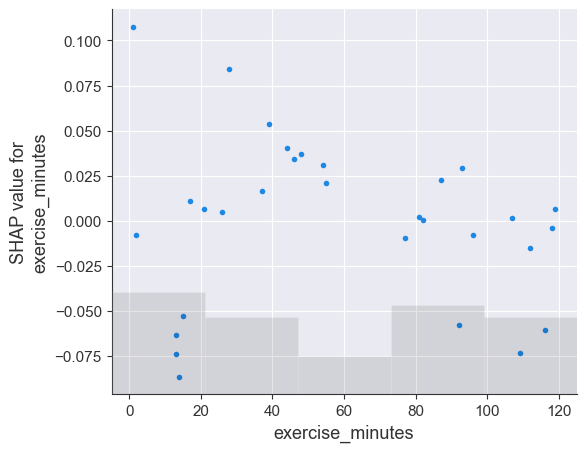

In [40]:
shap_values_xgb, top_features_xgb = shap_analysis_classification(
    best_xgb,
    X_shap,
    "XGBoost",
    class_index
)


========== SHAP Analysis: Random Forest ==========

1. Summary plot


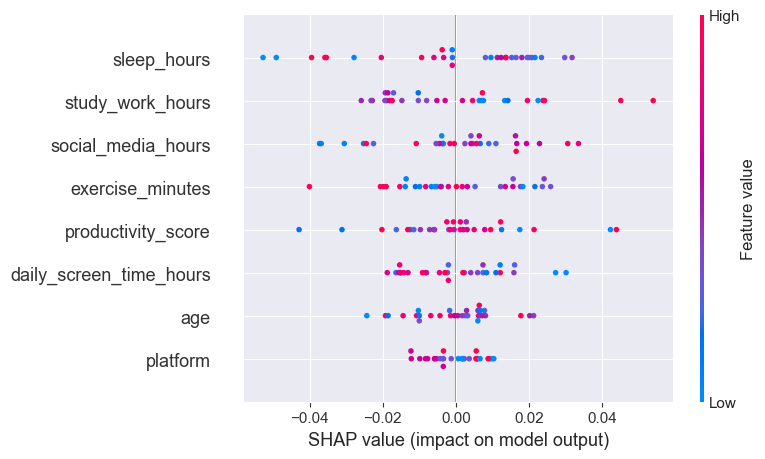


2. Bar plot


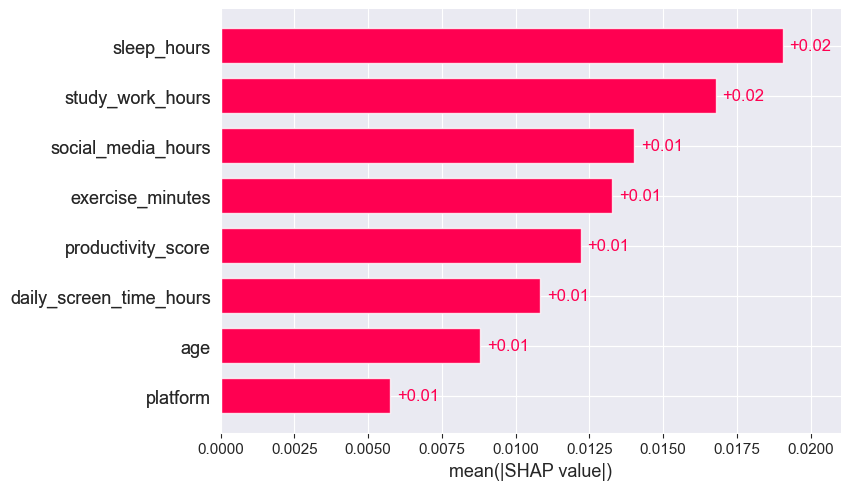


3. Waterfall plot pentru prima predictie


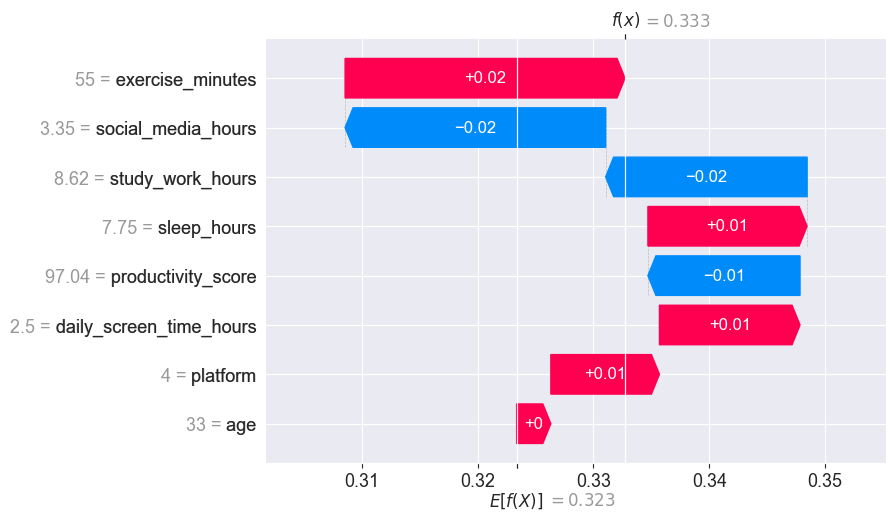


4. Force plot pentru prima predictie



Cele mai importante 3 caracteristici:
- sleep_hours: 0.0191
- study_work_hours: 0.0168
- social_media_hours: 0.0140

5. Scatter plots pentru cele mai importante 3 caracteristici

Scatter plot pentru: sleep_hours


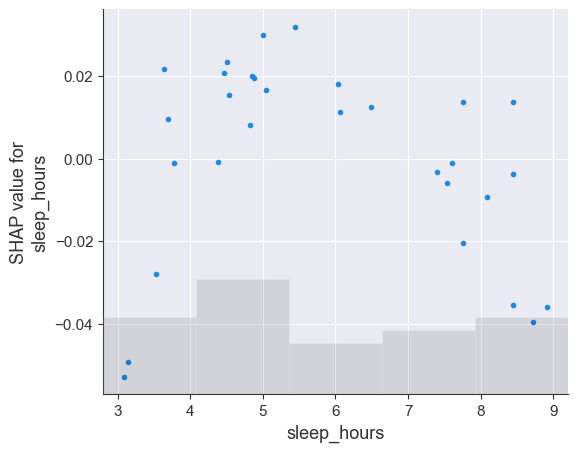


Scatter plot pentru: study_work_hours


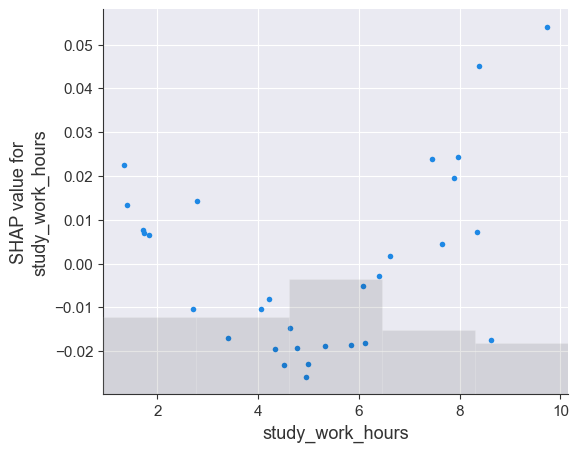


Scatter plot pentru: social_media_hours


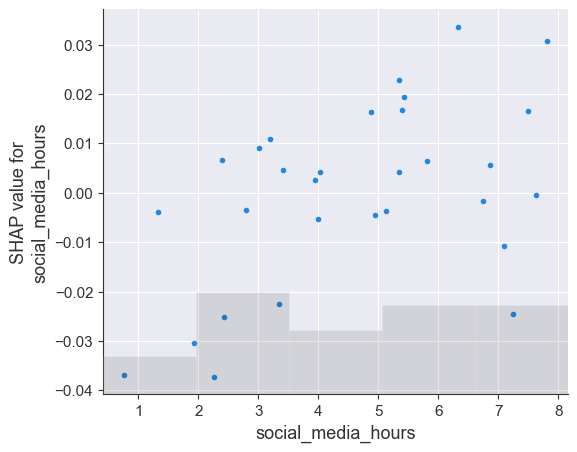

In [41]:
shap_values_rf, top_features_rf = shap_analysis_classification(
    best_rf,
    X_shap,
    "Random Forest",
    class_index
)

In [42]:
all_shap_results = {
    "CatBoost": shap_values_cat,
    "XGBoost": shap_values_xgb,
    "Random Forest": shap_values_rf
}

all_top_features = {
    "CatBoost": top_features_cat,
    "XGBoost": top_features_xgb,
    "Random Forest": top_features_rf
}

In [43]:
for model_name, features in all_top_features.items():
    print(f"\n{model_name}")
    print("Top 3 caracteristici importante:")
    for feature in features:
        print(f"- {feature}")


CatBoost
Top 3 caracteristici importante:
- sleep_hours
- exercise_minutes
- daily_screen_time_hours

XGBoost
Top 3 caracteristici importante:
- sleep_hours
- study_work_hours
- exercise_minutes

Random Forest
Top 3 caracteristici importante:
- sleep_hours
- study_work_hours
- social_media_hours


## 4.6 Explicabilitatea si analiza SHAP – Classification

Pentru interpretarea modelelor perfectionate de clasificare au fost analizate **CatBoost**, **XGBoost** si **Random Forest** folosind SHAP prin:
- **Summary plot** pentru explicatie globala
- **Bar plot** pentru importanta caracteristicilor
- **Waterfall plot** pentru explicatie locala
- **Force plot** pentru influenta individuala asupra predictiei

### CatBoost
Top 3 caracteristici:
- **sleep_hours**
- **exercise_minutes**
- **daily_screen_time_hours**

Conform summary si bar plot, **sleep_hours** este cea mai importanta variabila, avand cea mai mare influenta asupra predictiei. **exercise_minutes** contribuie pozitiv, iar **daily_screen_time_hours** afecteaza rezultatul in functie de intensitate.
Waterfall plot-ul arata ca pentru prima predictie, **exercise_minutes** a avut cea mai mare contributie pozitiva.

### XGBoost
Top 3 caracteristici:
- **sleep_hours**
- **study_work_hours**
- **exercise_minutes**

Modelul confirma importanta majora a somnului, dar evidentiaza si rolul **study_work_hours**, ceea ce sugereaza ca timpul dedicat activitatilor productive influenteaza semnificativ clasificarea.
Explicatiile locale arata variatii clare intre contributiile pozitive si negative ale caracteristicilor.

### Random Forest
Top 3 caracteristici:
- **sleep_hours**
- **study_work_hours**
- **social_media_hours**

Random Forest pastreaza **sleep_hours** ca factor dominant, dar introduce **social_media_hours** intre cele mai relevante caracteristici, indicand o sensibilitate mai mare la comportamentul digital.

## Analiza globala
Toate cele 3 modele arata constant ca:
- **sleep_hours** este cel mai important predictor
- **exercise_minutes** si **study_work_hours** influenteaza puternic predictiile
- Variabilele digitale (**daily_screen_time_hours**, **social_media_hours**) au impact diferit in functie de model

## Analiza locala
Waterfall si force plot-urile arata clar cum anumite caracteristici pot creste sau reduce probabilitatea unei clase pentru o observatie individuala.
Exemplu: in CatBoost, valori mari pentru **exercise_minutes** cresc predictia, in timp ce anumite valori pentru **social_media_hours** pot reduce scorul.

## Concluzii finale
- SHAP a permis interpretarea corecta atat globala, cat si locala a modelelor.
- **sleep_hours** este cea mai importanta caracteristica in toate modelele perfectionate.
- CatBoost si XGBoost ofera explicatii mai stabile si mai clare decat Random Forest.
- Modelele sugereaza ca somnul, activitatea fizica si organizarea timpului au cel mai mare impact asupra clasificarii finale.

Analiza confirma ca modelele perfectionate sunt coerente, interpretabile si bazate pe factori relevanti logic.

In [44]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

joblib.dump(best_cat, "saved_models/classification_catboost.pkl")
joblib.dump(best_xgb, "saved_models/classification_xgboost.pkl")
joblib.dump(best_rf, "saved_models/classification_random_forest.pkl")
joblib.dump(best_svm, "saved_models/classification_svm.pkl")
joblib.dump(best_nb, "saved_models/classification_nb.pkl")

joblib.dump(scaler, "saved_models/classification_scaler.pkl")
joblib.dump(le_target, "saved_models/classification_target_encoder.pkl")
joblib.dump(le_platform, "saved_models/classification_platform_encoder.pkl")

['saved_models/classification_platform_encoder.pkl']

In [46]:
joblib.dump(X.columns.tolist(), "saved_models/classification_columns.pkl")

['saved_models/classification_columns.pkl']